# Cartel vs. Security Forces: A Temporal View — Mexico, 2018–2024\n\nThe companion notebook, `cartel_network_timeline.ipynb`, 

tracks *who cartels fight among themselves*. This notebook asks a different question of the same event stream: **when, how often, and against which arm of the Mexican state do cartels actually clash?**\n\nACLED tags every actor with an `inter` code — `Political militia` for organized armed groups (cartels), `State forces` for police and military. Filtering the Mexico event stream to rows where one side is tagged `State forces` and the other `Political militia`, restricted to armed confrontations (`Battles`/`Armed clash` and `Explosions/Remote violence`), isolates exactly the clashes this notebook is about — not the far larger set of protests, cartel-on-cartel fighting, or violence against civilians that dominate the wider dataset.\n\nThe notebook has four parts:\n1. **Build the clash dataset** — reusing the cartel name-normalization logic from the network notebook, plus a new classifier for which branch of the state (military, National Guard, federal/state/municipal police) was on the other side.\n2. **The core timeline** — monthly clash frequency and fatalities, 2018–2024.\n3. **Who the state is fighting** — which cartels account for the clashes, and how that mix shifted year to year.\n4. **Which arm of the state is fighting** — the military/police composition of those clashes over time, and where geographically the front line moved."


## 1. Setup

In [9]:
import re

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)

# Categorical / sequential palette (dataviz skill reference palette, light-mode values) —
# same palette as cartel_network_timeline.ipynb for visual consistency across the two notebooks.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
MUTED = "#c3c2b7"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"

## 2. Building the clash dataset

### Load Mexico events

Same chunked-read approach as the network notebook — the full LATAM file is 273MB / ~434k rows, too large to load whole, so stream it in chunks and keep only Mexico with the columns needed here.

In [10]:
cols = [
    "country", "event_date", "year", "event_type", "sub_event_type", "actor1", "actor2",
    "inter1", "inter2", "admin1", "location", "latitude", "longitude", "fatalities", "notes",
]
chunks = pd.read_csv("LATAM 20241209.csv", usecols=cols, chunksize=200_000)
mex = pd.concat([c[c["country"] == "Mexico"] for c in chunks], ignore_index=True)
mex["event_date"] = pd.to_datetime(mex["event_date"])

print(f"Mexico events, {mex['year'].min()}–{mex['year'].max()}: {len(mex):,}\n")
print("inter1 (actor1's category):")
print(mex["inter1"].value_counts())
print("\ninter2 (actor2's category):")
print(mex["inter2"].value_counts())

Mexico events, 2018–2024: 95,647

inter1 (actor1's category):
inter1
Political militia        48966
Protesters               38079
Rioters                   4978
State forces              3071
Identity militia           437
Civilians                  104
External/Other forces       10
Rebel group                  2
Name: count, dtype: int64

inter2 (actor2's category):
inter2
Civilians                43920
State forces              7464
Political militia         4126
Rioters                    395
Identity militia           250
External/Other forces      168
Protesters                  77
Rebel group                  5
Name: count, dtype: int64


### Naming the two sides

**Cartel side** — identical normalization to `cartel_network_timeline.ipynb`: strip ACLED's leading acronym tag and trailing year-range/country suffixes, map recurring aliases to one canonical name, and keep only actors ACLED tags `Political militia`, excluding political parties and non-cartel actors that ACLED tags the same way. See that notebook for the full rationale.

**State side** — a new classifier, since the question here is specifically *which arm of the state*. ACLED's `actor` text names the force branch directly (e.g. `"Police Forces of Mexico (2018-) National Guard"`), so this is a simple substring match into six buckets: Military, National Guard, Federal Police (folds in "Ministerial Federal Police"), State Police, municipal/unspecified Police, and a residual Other (prison guards, "Government of Mexico" — together under 1% of rows).

In [11]:
EXCLUDE_PATTERNS = [
    r"^Unidentified", r"^Police Forces", r"^Military Forces", r"^Self-Defense",
    r"Communal Militia", r"^Civilians", r"National Guard", r"^Protesters",
    r"^Rioters", r"Health Workers", r"Government of Mexico", r"^Journalists",
    r"Policia Comunitaria", r"^Rebel Group", r"Prison Guards",
    # political parties/coalitions -- ACLED still tags these "Political militia" when they clash
    r"^(PRI|PRD|PAN|MORENA|MC|PT|PVEM|PES|RSP|FXM):",
    r"Institutional Revolutionary Party", r"Party of the Democratic Revolution",
    r"National Regeneration Movement", r"Strength and Heart for Mexico",
    r"National Action Party", r"Broad Front for Mexico", r"Citizens Movement",
    r"Labor Party \(Mexico\)", r"Ecologist Green Party",
]
EXCLUDE_RE = re.compile("|".join(EXCLUDE_PATTERNS))

CANON = {
    "Jalisco New Generation": "CJNG", "Sinaloa": "Sinaloa Cartel",
    "CDN": "Cartel del Noreste", "Golfo": "Gulf Cartel (Golfo)", "Gulf": "Gulf Cartel (Golfo)",
    "Los Chapitos": "Los Chapitos (Sinaloa)", "CU": "Carteles Unidos", "United Cartels": "Carteles Unidos",
    "Los Caballeros Templarios": "Caballeros Templarios",
}


def clean_name(name):
    if pd.isna(name):
        return None
    n = name.strip()
    n = re.sub(r"^[A-Z0-9]{2,6}:\s*", "", n)
    n = re.sub(r"\s*\(\d{4}-?\d*\)\s*", " ", n)
    n = re.sub(r"\s*\(Mexico\)\s*", " ", n)
    n = re.sub(r"\s+(Cartel|Gang|Group)$", "", n).strip()
    return n


def canon_name(raw):
    if pd.isna(raw) or EXCLUDE_RE.search(raw):
        return None
    c = clean_name(raw)
    return CANON.get(c, c)


BRANCH_ORDER = ["Military", "National Guard", "Federal Police", "State Police", "Police (unspecified)", "Other"]
BRANCH_COLORS = dict(zip(BRANCH_ORDER, [BLUE, ORANGE, AQUA, YELLOW, MUTED, SECONDARY_INK]))


def classify_branch(actor):
    if pd.isna(actor):
        return None
    if "Military Forces" in actor:
        return "Military"
    if "National Guard" in actor:
        return "National Guard"
    if "Ministerial Federal Police" in actor or "Federal Police" in actor:
        return "Federal Police"
    if "State Police" in actor:
        return "State Police"
    if "Prison Guards" in actor or "Government of Mexico" in actor:
        return "Other"
    return "Police (unspecified)"

### Isolating the clashes

A clash here means: `event_type` is `Battles` (ACLED's `Armed clash` sub-type) or `Explosions/Remote violence` (ambushes with IEDs, grenades, drone strikes) — and one side is `State forces`, the other `Political militia`. This deliberately excludes ACLED's `Strategic developments` rows (arrests, weapons seizures, property destruction — 1,134 rows) since those aren't armed confrontations, and drops any row where the cartel-side actor doesn't resolve to a named cartel (unidentified gunmen, generic "civilians", etc.).

In [12]:
CLASH_TYPES = ["Battles", "Explosions/Remote violence"]
is_clash = mex["event_type"].isin(CLASH_TYPES) & (
    ((mex["inter1"] == "State forces") & (mex["inter2"] == "Political militia"))
    | ((mex["inter2"] == "State forces") & (mex["inter1"] == "Political militia"))
)
sub = mex[is_clash].copy()

state_is_actor1 = sub["inter1"] == "State forces"
sub["cartel"] = np.where(state_is_actor1, sub["actor2"].apply(canon_name), sub["actor1"].apply(canon_name))
sub["branch"] = np.where(state_is_actor1, sub["actor1"].apply(classify_branch), sub["actor2"].apply(classify_branch))
sub = sub.dropna(subset=["cartel"]).reset_index(drop=True)

print(f"Cartel-vs-security-forces clashes, 2018–2024: {len(sub):,}")
print(f"Total fatalities in these clashes: {sub['fatalities'].sum():,}")
sub.head()

Cartel-vs-security-forces clashes, 2018–2024: 829
Total fatalities in these clashes: 1,379


,event_date,year,event_type,sub_event_type,actor1,inter1,actor2,inter2,country,admin1,location,latitude,longitude,notes,fatalities,cartel,branch
0,2024-11-29,2024,Battles,Armed clash,Los Chapitos Gang,Political militia,Military Forces of Mexico (2018-),State forces,Mexico,Sinaloa,Mojolo,24.8839,-107.4165,"On 29 November 2024, in Mojolo, Sinaloa, there...",3,Los Chapitos (Sinaloa),Military
1,2024-11-28,2024,Battles,Armed clash,Military Forces of Mexico (2018-),State forces,CJNG: Jalisco New Generation Cartel,Political militia,Mexico,Chiapas,Tapachula de Cordova y Ordonez,14.9111,-92.2643,"On 28 November 2024, in Tapachula de Cordova y...",2,CJNG,Military
2,2024-11-26,2024,Battles,Armed clash,CJNG: Jalisco New Generation Cartel,Political militia,Police Forces of Mexico (2018-) National Guard,State forces,Mexico,Jalisco,Lagos de Moreno,21.3564,-101.9292,"Around 26 November 2024 (as reported), in Lago...",0,CJNG,National Guard
3,2024-11-20,2024,Battles,Armed clash,Los Palacios Gang,Political militia,Military Forces of Mexico (2018-),State forces,Mexico,Mexico,San Pedro Cholula,19.2654,-99.4858,"On 20 November 2024, in San Pedro Cholula, Mex...",0,Los Palacios,Military
4,2024-11-18,2024,Battles,Armed clash,Police Forces of Mexico (2018-) State Police,State forces,CJNG: Jalisco New Generation Cartel,Political militia,Mexico,Michoacan de Ocampo,Tzurumutaro,19.5466,-101.5896,"On 18 November 2024, in Tzurumutaro, Michoacan...",0,CJNG,State Police


**What it shows:** **829 clashes** between named cartels and Mexican security forces are recorded 2018–2024, causing **1,379 fatalities** — a small slice of Mexico's ~434K-row share of the ACLED dataset, but a distinct and trackable one. That's roughly 10 clashes and 16 deaths per month on average, though (as the next section shows) the real pattern is far from a smooth average — it's a handful of very deadly single incidents layered on a steadier background rate.

## 3. The core timeline — clashes and fatalities by month

Two panels sharing one time axis: monthly clash count on top, monthly fatalities below. Each shows the raw monthly bars plus a 6-month rolling average (dark line) so the underlying trend is visible through the month-to-month noise. Keeping count and fatalities as two separate panels — rather than overlaying them on twin y-axes — avoids implying a false shared scale between "how often" and "how deadly."

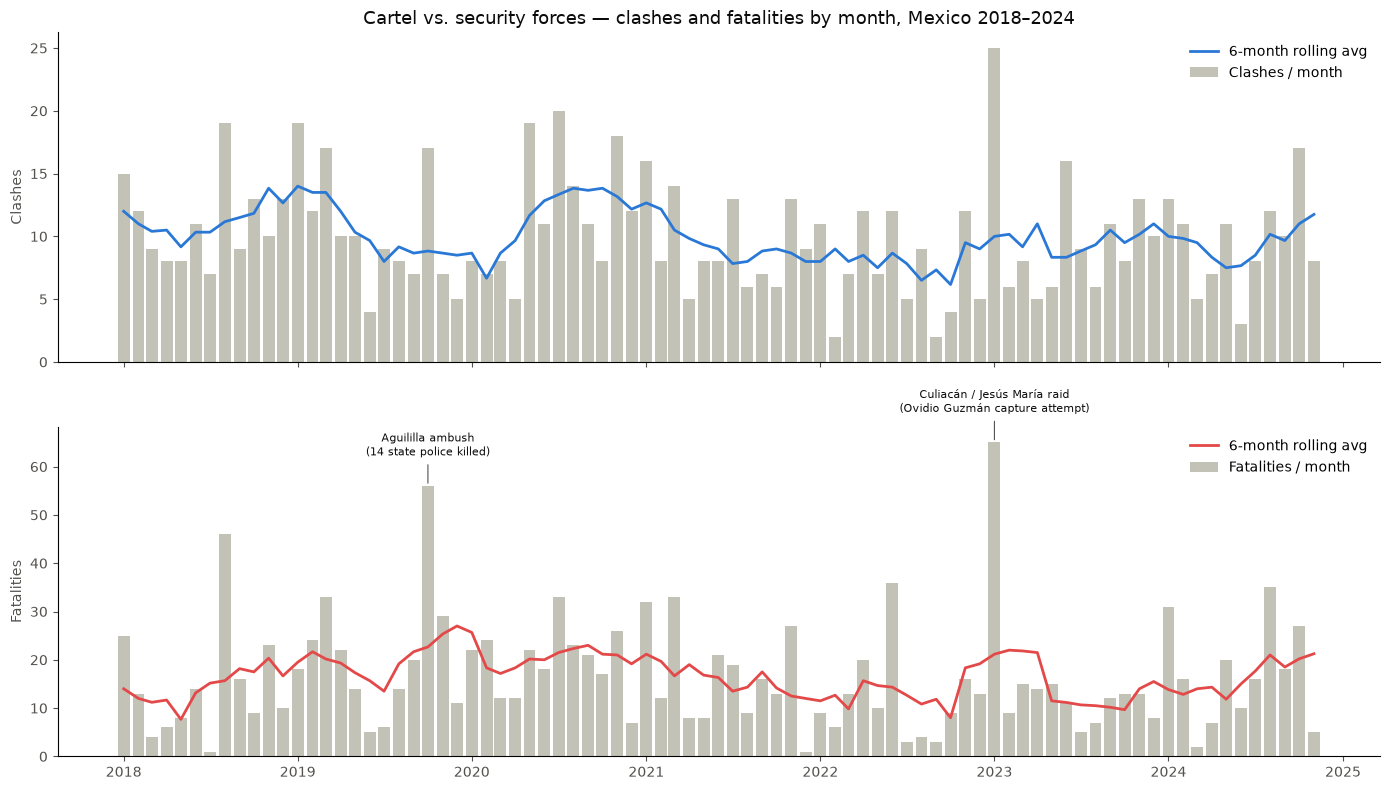

In [13]:
sub["ym"] = sub["event_date"].dt.to_period("M").dt.to_timestamp()
monthly = sub.groupby("ym").agg(clashes=("cartel", "size"), fatalities=("fatalities", "sum")).asfreq("MS", fill_value=0)
monthly["clashes_roll"] = monthly["clashes"].rolling(6, center=True, min_periods=1).mean()
monthly["fatalities_roll"] = monthly["fatalities"].rolling(6, center=True, min_periods=1).mean()

ANNOTATIONS = [
    ("2023-01-01", "Culiacán / Jesús María raid\n(Ovidio Guzmán capture attempt)"),
    ("2019-10-01", "Aguililla ambush\n(14 state police killed)"),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(monthly.index, monthly["clashes"], width=25, color=MUTED, label="Clashes / month")
axes[0].plot(monthly.index, monthly["clashes_roll"], color=BLUE, linewidth=2, label="6-month rolling avg")
axes[0].set_ylabel("Clashes", color=SECONDARY_INK)
axes[0].set_title("Cartel vs. security forces — clashes and fatalities by month, Mexico 2018–2024", fontsize=13, color=INK)
axes[0].legend(frameon=False, loc="upper right")

axes[1].bar(monthly.index, monthly["fatalities"], width=25, color=MUTED, label="Fatalities / month")
axes[1].plot(monthly.index, monthly["fatalities_roll"], color=RED, linewidth=2, label="6-month rolling avg")
axes[1].set_ylabel("Fatalities", color=SECONDARY_INK)
axes[1].legend(frameon=False, loc="upper right")

for date, text in ANNOTATIONS:
    ts = pd.Timestamp(date)
    y = monthly.loc[ts, "fatalities"]
    axes[1].annotate(text, xy=(ts, y), xytext=(0, 22), textcoords="offset points",
                      ha="center", fontsize=8, color=INK,
                      arrowprops=dict(arrowstyle="-", color=SECONDARY_INK, lw=0.8))

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=SECONDARY_INK)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

**What it shows:** Unlike total event volume in the wider dataset (which climbs steadily 2018→2024), clash frequency with security forces has **no secular trend** — it oscillates between 88 and 141 clashes a year with no sustained rise or fall, averaging a little under 10 a month throughout the window. Fatalities are a different story: they don't track clash *count* at all. The deadliest month in the whole series, **January 2023 (65 dead across 25 clashes)**, is the military's attempt to recapture Ovidio Guzmán in Culiacán/Jesús María, Sinaloa. **October 2019 (56 dead)** includes the Aguililla ambush that killed 14 state police in a single CJNG attack. Both spikes are one or two extreme incidents distorting an otherwise steady month — the rolling average makes clear that the "typical" month is far less violent than these headlines suggest.

## 4. Who the state is fighting — top cartels over time

Yearly clash counts broken out by cartel, for the five cartels with the most total clashes against security forces 2018–2024, with everyone else folded into "Other cartels."

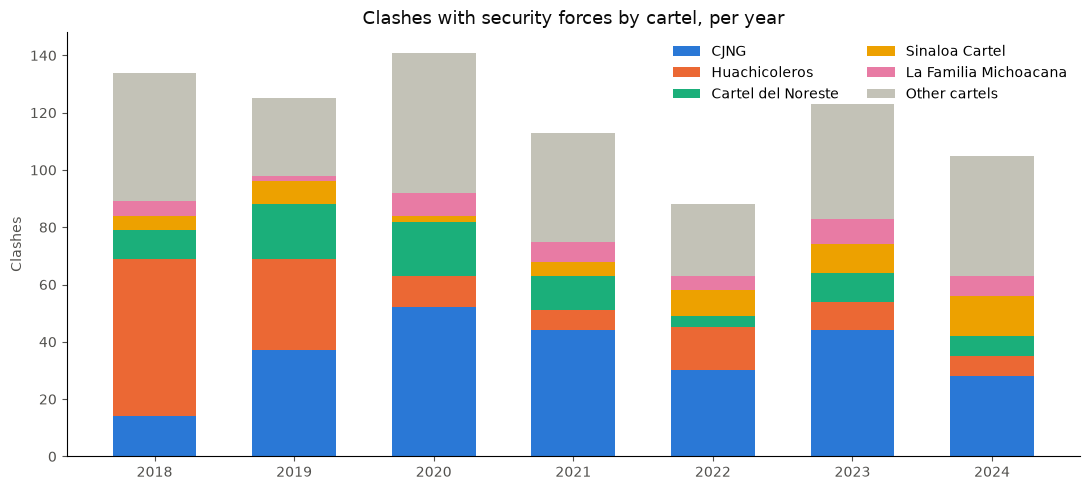

cartel_bucket,CJNG,Huachicoleros,Cartel del Noreste,Sinaloa Cartel,La Familia Michoacana,Other cartels
year,,,,,,
2018,14,55,10,5,5,45
2019,37,32,19,8,2,27
2020,52,11,19,2,8,49
2021,44,7,12,5,7,38
2022,30,15,4,9,5,25
2023,44,10,10,10,9,40
2024,28,7,7,14,7,42


In [14]:
TOP_CARTELS = sub["cartel"].value_counts().head(5).index.tolist()
CARTEL_COLORS = dict(zip(TOP_CARTELS, [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]))
CARTEL_COLORS["Other cartels"] = MUTED

sub["cartel_bucket"] = np.where(sub["cartel"].isin(TOP_CARTELS), sub["cartel"], "Other cartels")
cartel_year = sub.groupby(["year", "cartel_bucket"]).size().unstack(fill_value=0)
cartel_year = cartel_year[TOP_CARTELS + ["Other cartels"]]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(cartel_year))
for col in cartel_year.columns:
    ax.bar(cartel_year.index.astype(str), cartel_year[col], bottom=bottom, color=CARTEL_COLORS[col], label=col, width=0.6)
    bottom += cartel_year[col].values

ax.set_title("Clashes with security forces by cartel, per year", fontsize=13, color=INK)
ax.set_ylabel("Clashes", color=SECONDARY_INK)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=SECONDARY_INK)
ax.legend(frameon=False, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

cartel_year

**What it shows:** **CJNG is the state's most consistent adversary** in every single year of the window (14 clashes in 2018, peaking at 52 in 2020, still 28 in 2024) — the same group that `cartel_network_timeline.ipynb` found sitting at the center of the cartel-on-cartel rivalry network is also the group most often fighting the state directly. The more striking pattern belongs to **Huachicoleros** ("fuel thieves"), the #2 cartel here overall: they account for 55 of the 134 clashes in 2018 alone, then collapse to single digits by 2021 (55 → 32 → 11 → 7). That timing lines up with the Mexican government's high-profile crackdown on pipeline fuel theft (*huachicol*) launched in January 2019 — visible directly in this event data as a near-vanishing of the group from armed clashes with the state within two years, concentrated almost entirely in **Hidalgo and Puebla** (86 of their 137 clashes), the heart of the pipeline-theft corridor.

## 5. Which arm of the state is fighting — branch composition over time

The same clashes, now broken out by which security-force branch was on the other side, as a share of that year's clashes. This is where institutional changes to Mexico's security apparatus — not just cartel behavior — show up directly in the data.

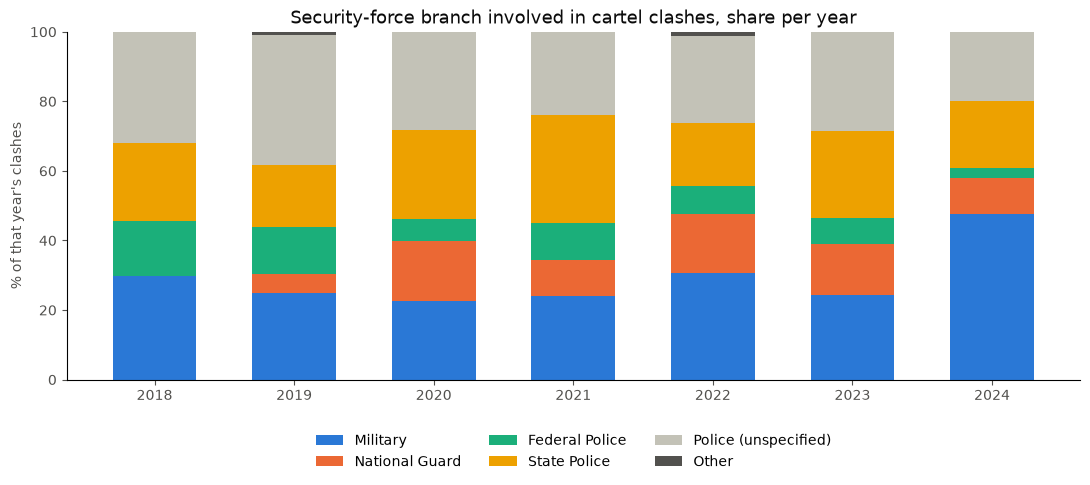

branch,Military,National Guard,Federal Police,State Police,Police (unspecified),Other
year,,,,,,
2018,29.9,0.0,15.7,22.4,32.1,0.0
2019,24.8,5.6,13.6,17.6,37.6,0.8
2020,22.7,17.0,6.4,25.5,28.4,0.0
2021,23.9,10.6,10.6,31.0,23.9,0.0
2022,30.7,17.0,8.0,18.2,25.0,1.1
2023,24.4,14.6,7.3,25.2,28.5,0.0
2024,47.6,10.5,2.9,19.0,20.0,0.0


In [15]:
branch_year = sub.groupby(["year", "branch"]).size().unstack(fill_value=0)
branch_year = branch_year[[c for c in BRANCH_ORDER if c in branch_year.columns]]
branch_share = branch_year.div(branch_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(branch_share))
for col in branch_share.columns:
    ax.bar(branch_share.index.astype(str), branch_share[col], bottom=bottom, color=BRANCH_COLORS[col], label=col, width=0.6)
    bottom += branch_share[col].values

ax.set_title("Security-force branch involved in cartel clashes, share per year", fontsize=13, color=INK)
ax.set_ylabel("% of that year's clashes", color=SECONDARY_INK)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=SECONDARY_INK)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

branch_share.round(1)

**What it shows:** Two real institutional shifts are visible directly in who cartels are shooting at. **Federal Police's share collapses from 15.7% (2018) to 2.9% (2024)**, and **National Guard's share rises from 0% (didn't exist) to 10–17%** from 2019 onward — the National Guard was created by constitutional reform in March 2019, absorbing much of the Federal Police's role, and the clash data tracks that handover almost exactly. Separately, **2024's military share (47.6%) is the highest of the whole window**, nearly double most prior years — driven largely by CJNG (13 clashes) and, notably, the **Sinaloa Cartel (10 clashes, up from a handful in prior years)**, consistent with the surge in military operations that followed the Sinaloa Cartel's internal "Chapitos vs. Mayos" war breaking into the open in mid-2024.

## 6. Where the fight moved — state-level clash intensity by year

A heatmap of the eight Mexican states with the most cartel-vs-security-forces clashes overall, one row per state, one column per year — a single sequential scale (darker = more clashes) so intensity reads directly as color depth, with no need for a legend beyond the color bar.

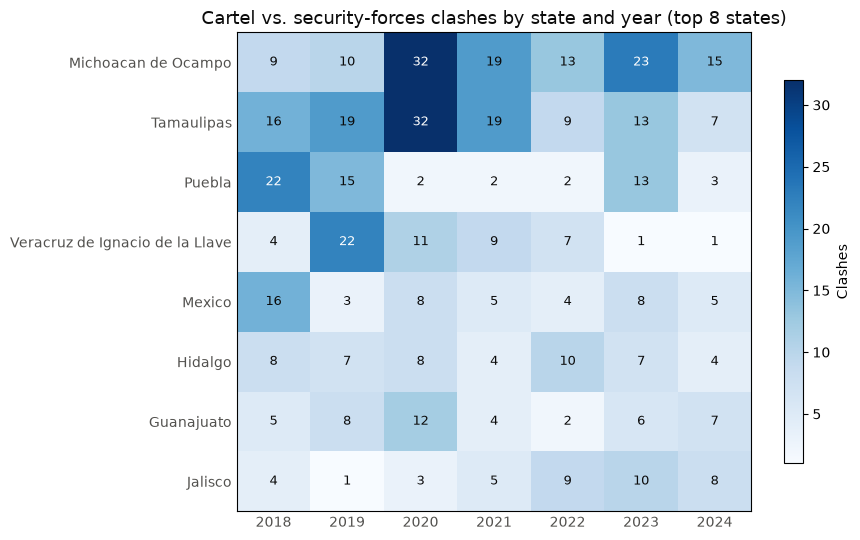

In [16]:
TOP_STATES = sub["admin1"].value_counts().head(8).index.tolist()
state_year = sub[sub["admin1"].isin(TOP_STATES)].groupby(["admin1", "year"]).size().unstack(fill_value=0)
state_year = state_year.loc[TOP_STATES]  # order rows by total clashes, most active first

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(state_year.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(state_year.columns)))
ax.set_xticklabels(state_year.columns.astype(str))
ax.set_yticks(range(len(state_year.index)))
ax.set_yticklabels(state_year.index)
ax.tick_params(colors=SECONDARY_INK, length=0)

vmax = state_year.values.max()
for i in range(state_year.shape[0]):
    for j in range(state_year.shape[1]):
        v = state_year.values[i, j]
        color = "white" if v > vmax * 0.6 else INK
        ax.text(j, i, v, ha="center", va="center", fontsize=9, color=color)

ax.set_title("Cartel vs. security-forces clashes by state and year (top 8 states)", fontsize=13, color=INK)
fig.colorbar(im, ax=ax, label="Clashes", shrink=0.8)
plt.tight_layout()
plt.show()

**What it shows:** The geography confirms the two stories above rather than adding a new one, which is itself a useful check. **Puebla** — the Huachicoleros' home turf — goes from the single hottest state in 2018 (22 clashes) to near-zero from 2020 on, the same fuel-theft-crackdown fade seen in Section 4. **Tamaulipas** and **Michoacán de Ocampo** are the two chronic fronts, both active in every single year and both peaking in 2020 (32 clashes each) — Tamaulipas from the Gulf Cartel/Cartel del Noreste fight along the US border, Michoacán from CJNG's home-region conflicts. **Jalisco**, CJNG's own home state, climbs steadily in the back half of the window (4 in 2018 → 9–10 by 2022–2023) as its national expansion (documented in the network notebook) brought more direct confrontation with the state closer to home rather than only on distant fronts.

## Summary

Clash *frequency* between cartels and the Mexican state is flat over 2018–2024, but almost everything else about it changes: which cartel is fighting (Huachicoleros collapse after the 2019 fuel-theft crackdown, CJNG stays constant), which arm of the state is fighting (Federal Police is phased out in favor of the National Guard, and the military's role spikes sharply in 2024), and where (Puebla fades, Tamaulipas/Michoacán persist, Jalisco rises). None of that composition shift would be visible from yearly totals alone — it only shows up once the same event stream is cut by cartel, by state-force branch, and by geography, and read as a time series rather than a single snapshot.